In [1]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from tqdm import tqdm

import pandas as pd

from scipy import stats 

from time import time

In [2]:
Prop = Propagator(elev=0)
Prop.set_H(0) #sets atmospheric depth to sea level (for calculations which use hg/cm^2)

In [3]:
Prop.load_ice_profile('Real_vs_ice_eq_depth.csv', 'DomeC_age_scale_Apr2023.csv')

In [4]:
Prop.set_energy_bins(logE_min = -1, logE_max = 11, logE_mu_max=7.5, dlogE=0.1)

In [5]:
Prop.set_zenith_bins(N_ang=10)

In [6]:
df_Pfast = pd.read_csv('Production Rates/P_fast_0m.csv')
df_Pneg = pd.read_csv('Production Rates/P_neg_0m.csv')
P_14C = np.swapaxes([df_Pfast.T, df_Pneg.T], 0, 1)
model_names = list(df_Pfast.columns)

In [7]:
Prop.Phi['prod']=P_14C[-1:]
C_flow = F.flow_14C(Prop)

100%|███████████████████████████████████████████████████████████████████████████| 7283/7283 [00:00<00:00, 19282.42it/s]


In [8]:
t_scale = (Prop.t[Prop.i_start:]-Prop.t[-1])/(Prop.t[-1]-Prop.t[Prop.i_start])
f_lin = t_scale

In [9]:
da = 0.01
a = np.arange(-0.5,0.5+da, da)
a_weights = np.ones(len(a))

In [10]:
C_flow_lin = F.flow_14C(Prop, f_lin)

100%|███████████████████████████████████████████████████████████████████████████| 7283/7283 [00:00<00:00, 19790.05it/s]


In [11]:
#df = pd.read_csv('14CO_f_all_ChiSq.csv')
#f_factors = np.array([df['fast'],df['f_neg']]).T[1:]
#f_weights = np.array(np.exp(-df['Chi_sq']/2))[1:] # convert chi^2 to prior weight

In [12]:
df = pd.read_csv('factors_2sigma_hull.csv', header=None)
f_factors = np.array([df[1],df[0]]).T
f_weights = np.ones(len(f_factors)) # convert chi^2 to prior weight

In [13]:
C_pred = C_flow @ Prop.S_mat[Prop.i_start:]
C_weights = np.ones(len(C_pred))

f_pure_avg = np.average(f_factors, weights=f_weights, axis=0)
C_norm = np.sum(f_pure_avg @ C_flow * Prop.dh[Prop.i_start:], axis=-1)

C_pred = C_pred / np.reshape(C_norm, (-1,1,1))
f_factors = f_factors * C_norm[-1]

In [14]:
C_lin = C_flow_lin @ Prop.S_mat[Prop.i_start:] / np.reshape(C_norm, (-1,1,1))

In [15]:
C_avg = np.average(C_pred, weights=C_weights, axis=0)
# axis0 - Production Mode
# axis1 - Sample Depth

#C_cov = np.reshape(
    #np.cov(np.reshape(C_pred, (len(C_pred), -1)), rowvar=False, aweights=C_weights),
    #(*np.shape(C_avg), *np.shape(C_avg)))
C_cov = np.zeros((2, len(Prop.z_samp), 2, len(Prop.z_samp)))
# axis0 - Production Mode A
# axis1 - Sample Depth A
# axis2 - Production Mode B
# axis3 - Sample Depth B

f_avg = np.average(f_factors, weights=f_weights, axis=0)
# axis0 - Production Mode

f_cov = np.cov(f_factors, rowvar=False, aweights=f_weights)
# axis0 - Production Mode A
# axis1 - Production Mode B

CO_avg = f_avg @ C_avg
# axis0 - Sample Depth

CO_cov = f_avg @ np.moveaxis(C_cov, (0,2), (-2,-1)) @ f_avg + C_avg.T @ f_cov @ C_avg + np.sum(C_cov * np.reshape(f_cov, (2,1,2,1)), axis=(0,2))
# axis0 - Sample Depth A
# axis1 - Sample Depth B

rel_err = 0.02 * np.ones(len(CO_avg))
# axis0 - Sample Depth

s_cov = np.diag(rel_err**2)
# axis0 - Sample Depth A
# axis1 - Sample Depth B

CO_samp_cov = CO_cov * (1+s_cov) + np.reshape(CO_avg, (-1,1)) * np.reshape(CO_avg, (1,-1)) * s_cov
# axis0 - Sample Depth A
# axis1 - Sample Depth B

CO_samp_cov_inv = np.linalg.inv(CO_samp_cov)

In [16]:
C_avg_lin = np.average(C_lin, weights=C_weights, axis=0)
CO_avg_lin = f_avg @ C_avg_lin

In [17]:
Sigma_f = np.reshape(f_avg@C_pred, (len(C_pred), -1, 1)) * np.reshape(f_avg@C_pred, (len(C_pred), 1, -1)) * s_cov  + np.swapaxes(C_pred, -2,-1) @ f_cov @ C_pred * (1+s_cov)

In [18]:
Sigma_f_inv = np.linalg.inv(Sigma_f)

In [19]:
def T(A):
    return np.swapaxes(A, -2, -1)

In [20]:
C_var = np.reshape(C_pred, (len(C_pred), 1, 2, -1)) + np.reshape(a, (1,-1,1,1)) * np.reshape(C_lin, (len(C_lin),1,2,-1))
#axis0 - model
#axis1 - amplitude
#axis2 - production mode
#axis3 - sample depth

Sigma_f_lin = np.reshape(f_avg@C_var, (len(C_var), len(a), -1, 1)) * np.reshape(f_avg@C_var, (len(C_var), len(a), 1, -1)) * s_cov  + T(C_var) @ f_cov @ C_var * (1+s_cov)

In [21]:
Sigma_f_lin_inv = np.linalg.inv(Sigma_f_lin)

In [22]:
np.shape(Sigma_f_lin_inv)

(1, 101, 11, 11)

In [23]:
np.shape(f_factors)

(118, 2)

In [24]:
np.shape(C_var)

(1, 101, 2, 11)

In [25]:
np.shape(f_factors @ C_var)

(1, 101, 118, 11)

In [26]:
def get_probs(N=1000, a_samp=0, samp_f=True, use_f=True, gauss_f=False):
    i = np.random.choice(np.arange(len(C_pred)), N, p=C_weights/np.sum(C_weights))
    s = np.random.normal(0,rel_err,(N,len(CO_avg)))
    if samp_f:
        j = np.random.choice(np.arange(len(f_factors)), N, p=f_weights/np.sum(f_weights))
        x = (np.reshape(f_factors[j], (-1,1,2))@(C_pred[i] + a_samp*C_lin[i]))[:,0]*(1+s)
    else:
        x = (np.reshape(f_avg, (1,1,2))@(C_pred[i] + a_samp*C_lin[i]))[:,0]*(1+s)
    
    if use_f:
        if gauss_f:
            dCO_0 = np.reshape(x, (len(x),1,-1,1))-np.reshape(f_avg@C_pred, (1,len(C_pred),-1,1))
            P_0 = np.sum(np.exp(-T(dCO_0)@Sigma_f_inv@dCO_0/2)[:,:,0,0]*np.reshape(C_weights/np.sqrt(np.linalg.det(2*np.pi*Sigma_f)), (1,-1)), axis=-1)/np.sum(C_weights)

            dCO_var = np.reshape(x, (len(x),1,1,-1,1))-np.reshape(f_avg@C_var, (1,len(C_var),len(a),-1,1))
            P_lin = np.sum(np.exp(-T(dCO_var)@Sigma_f_lin_inv@dCO_var/2)[:,:,:,0,0]/np.reshape(np.sqrt(np.linalg.det(2*np.pi*Sigma_f_lin)), (1,len(C_var),-1))*np.reshape(a_weights, (1,1,-1))*np.reshape(C_weights, (1,-1,1)), axis=(1,2))/np.sum(a_weights)/np.sum(C_weights)
        else:
            dCO_0 = ((np.reshape(x, (len(x),1,1,-1))/np.reshape(f_factors@C_pred, (1,len(C_pred),len(f_factors),-1)))-1)/np.reshape(rel_err, (1,1,1,-1))
            P_0 = np.sum(np.exp(np.sum(-dCO_0**2/2,axis=-1))/np.reshape(np.prod(np.sqrt(2*np.pi)*np.reshape(rel_err,(1,1,-1))*(f_avg@C_pred),axis=-1), (1,len(C_pred),-1))*np.reshape(f_weights, (1,1,-1))*np.reshape(C_weights, (1,-1,1)), axis=(1,2))/np.sum(C_weights)/np.sum(f_weights)

            dCO_var = ((np.reshape(x, (len(x),1,1,1,-1))/np.reshape(f_factors@C_var, (1,len(C_var),len(a),len(f_factors),-1)))-1)/np.reshape(rel_err, (1,1,1,1,-1))
            P_lin = np.sum(np.exp(np.sum(-dCO_var**2/2,axis=-1))/np.reshape(np.prod(np.sqrt(2*np.pi)*np.reshape(rel_err,(1,1,1,-1))*(f_avg@C_var),axis=-1), (1,len(C_var),len(a),-1))*np.reshape(a_weights, (1,1,-1,1))*np.reshape(C_weights, (1,-1,1,1))*np.reshape(f_weights,(1,1,1,-1)), axis=(1,2,3))/np.sum(C_weights)/np.sum(a_weights)/np.sum(f_weights)
        
    else:
        dCO_0 = ((np.reshape(x, (len(x),1,-1))/np.reshape(f_avg@C_pred, (1,len(C_pred),-1)))-1)/np.reshape(rel_err, (1,1,-1))
        P_0 = np.sum(np.exp(np.sum(-dCO_0**2/2,axis=-1))*np.reshape(C_weights/np.prod(np.sqrt(2*np.pi)*np.reshape(rel_err,(1,-1))*(f_avg@C_pred),axis=-1),(1,-1)), axis=-1)/np.sum(C_weights)
        
        dCO_var = ((np.reshape(x, (len(x),1,1,-1))/np.reshape(f_avg@C_var, (1,len(C_var),len(a),-1)))-1)/np.reshape(rel_err, (1,1,1,-1))
        P_lin = np.sum(np.exp(np.sum(-dCO_var**2/2,axis=-1))/np.reshape(np.prod(np.sqrt(2*np.pi)*np.reshape(rel_err,(1,1,-1))*(f_avg@C_var),axis=-1), (1,len(C_var),-1))*np.reshape(a_weights, (1,1,-1))*np.reshape(C_weights, (1,-1,1)), axis=(1,2))/np.sum(C_weights)/np.sum(a_weights)
    
    return P_0, P_lin

In [27]:
#P = np.reshape(np.swapaxes([get_probs() for i in tqdm(range(10))], 0,1), (2,-1))

In [28]:
#P = [get_probs(100) for i in tqdm(range(100))]

In [29]:
#P = [get_probs(10000) for i in tqdm(range(1))]

In [30]:
M = 100
N = 1000
P = np.reshape(np.swapaxes([get_probs(M, samp_f=False, use_f=True, gauss_f=True) for i in tqdm(range(N))], 0,1), (2,-1))

100%|█████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:05<00:00, 178.16it/s]


In [31]:
B_01 = P[0]/P[1]

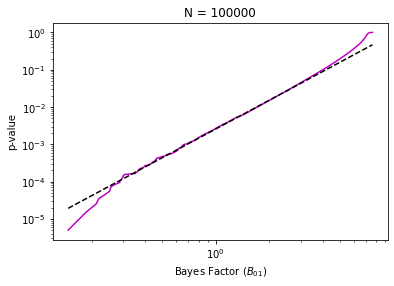

In [32]:
B = np.sort(B_01)
p = (np.arange(len(B_01))+0.5)/len(B_01)

coef = np.polyfit(np.log(B[:1000]),np.log(p[:1000]),1)
poly1d_fn = np.poly1d(coef) 
#poly1d_fn is now a function which takes in x and returns an estimate for y

plt.plot(B,p, '-m')
plt.plot(B, np.exp(poly1d_fn(np.log(B))), '--k')
plt.xscale('log')
plt.xlabel(r'Bayes Factor ($B_{01}$)')
plt.yscale('log')
plt.ylabel('p-value')
plt.title('N = {}'.format(N*M))
plt.show()

In [33]:
print(B)

[0.14774741 0.18610761 0.21215477 ... 7.5783695  7.57914922 7.62098783]


In [34]:
coef

array([ 2.5614082 , -5.96251365])

In [35]:
# ln(p) = coef[0]*ln(B) + coef[1]
# ln(B) = (ln(p)-coef[1])/coef[0]
sigs = [3,4,5]
B_thr = [np.exp((np.log(stats.norm.sf(s)*2)-coef[1])/coef[0]) for s in sigs]

In [36]:
[stats.norm.sf(s)*2 for s in sigs]

[0.002699796063260186, 6.334248366623973e-05, 5.733031437583867e-07]

In [37]:
B_thr

[1.0188903680808559, 0.23545120616635948, 0.03751210770938781]

In [38]:
P_var = np.swapaxes([get_probs(1000, a_samp=a_samp, samp_f=False, use_f=True, gauss_f=True) for a_samp in tqdm(a)], 0,1)

100%|████████████████████████████████████████████████████████████████████████████████| 101/101 [00:06<00:00, 16.17it/s]


In [39]:
B_var = P_var[0]/P_var[1]

In [40]:
discovery = np.array([np.sum(B_var<=b, axis=-1)/np.shape(B_var)[-1] for b in B_thr])

In [41]:
sensitivity_low = a[np.array([np.arange(len(discovery[i]))[discovery[i]<0.5][0]-1 for i in range(len(discovery))])]
sensitivity_high = a[np.array([np.arange(len(discovery[i]))[discovery[i]<0.5][-1]+1 for i in range(len(discovery))])]

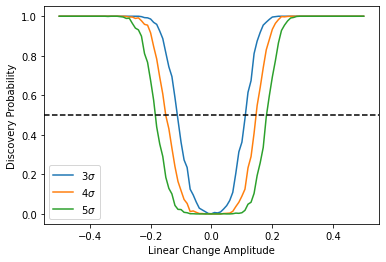

In [42]:
for i,d in enumerate(discovery):
    plt.plot(a, d, label=r'{}$\sigma$'.format(sigs[i]))
plt.axhline(0.5, c='k', ls='--')
plt.xlabel('Linear Change Amplitude')
plt.ylabel('Discovery Probability')
plt.legend()
plt.show()

In [43]:
print(sensitivity_low)
print(sensitivity_high)

[-0.12 -0.16 -0.19]
[0.12 0.15 0.19]


In [91]:
#f = np.array([df['fast'],df['f_neg']]).T
#f_w = np.array(np.exp(-df['Chi_sq']/2)) # convert chi^2 to prior weight
f = np.array([df[1],df[0]]).T
f_w = np.ones(len(f))

f_avg = np.average(f, weights=f_w, axis=0)
f_cov = np.cov(f, rowvar=False, aweights=f_w)

In [92]:
f_fast = np.reshape(f[:,0], (201,201))[0]
f_neg = np.reshape(f[:,1], (201,201)).T[0]
f_w = np.reshape(f_w, (201,201))

ValueError: cannot reshape array of size 118 into shape (201,201)

In [54]:
#df = np.reshape(f-f_avg, (201,201,2,1))

In [55]:
#f_w_gauss = np.exp(-T(df)@np.linalg.inv(f_cov)@df/2)[:,:,0,0]

Text(0, 0.5, 'f_neg')

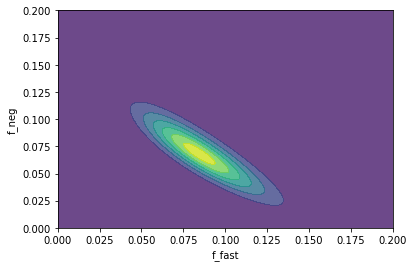

In [56]:
#plt.contourf(f_fast, f_neg, f_w, alpha=0.8)
#plt.xlabel('f_fast')
#plt.ylabel('f_neg')

(0.0, 0.2)

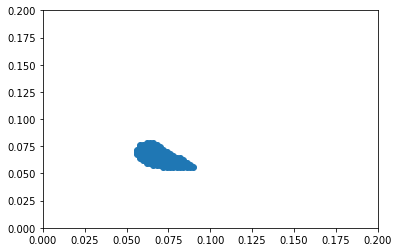

In [94]:
plt.scatter(f[:,0],f[:,1])
plt.xlim(0,0.2)
plt.ylim(0,0.2)

Text(0, 0.5, 'f_neg')

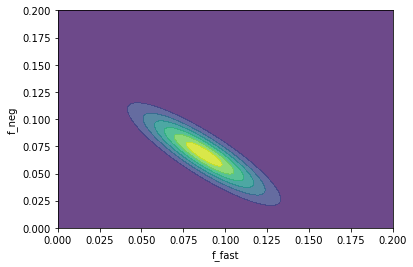

In [57]:
#plt.contourf(f_fast, f_neg, f_w_gauss, alpha=0.8)
#plt.xlabel('f_fast')
#plt.ylabel('f_neg')

Text(0, 0.5, 'f_neg')

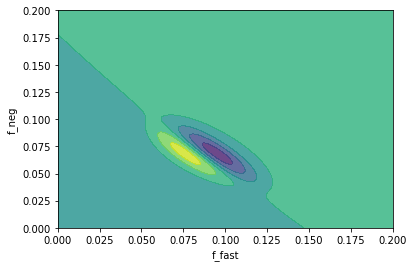

In [58]:
#plt.contourf(f_fast, f_neg, f_w-f_w_gauss, alpha=0.8)
#plt.xlabel('f_fast')
#plt.ylabel('f_neg')